# Laboratory 3 — Part B: Feature Engineering for Image Data
Grayscale conversion and pixel flattening, plus Home-Lab Exercises 3 and 4 and the Home Assignment.

> **Note:** the original notebook pointed to `lena.jpg` on a Windows desktop path. Here `image_file_path` points to a sample photograph in `sample_images/` so the notebook runs on any machine. Change it to your own file if you like — if the path does not exist the code falls back to a dummy image, exactly as in the lab handout.

## Task 3.2 — Converting and flattening image pixels

In [1]:
import numpy as np
from PIL import Image
import os

# Set to None to use a dummy image, or to a path string for your own image.
image_file_path = "sample_images/photo.jpg"

original_image = None
if image_file_path and os.path.exists(image_file_path):
    try:
        original_image = Image.open(image_file_path)
        print(f"--- Loaded Image from File: {image_file_path} ---")
    except Exception as e:
        print(f"Error loading image from {image_file_path}: {e}")
        dummy = np.random.randint(0, 256, size=(100, 100, 3), dtype=np.uint8)
        original_image = Image.fromarray(dummy, 'RGB')
        print("--- Created Dummy Image (100x100 RGB) ---")
else:
    print("No valid image file path provided or file not found.")
    dummy = np.random.randint(0, 256, size=(100, 100, 3), dtype=np.uint8)
    original_image = Image.fromarray(dummy, 'RGB')
    print("--- Created Dummy Image (100x100 RGB) ---")

original_image = original_image.convert('RGB')
original_image_array = np.array(original_image)

h, w, c = original_image_array.shape
print(f"Original Image Size (H, W, Channels): {original_image_array.shape}")
print(f"Total Features (Pixels) in RGB: {h * w * c}")

--- Loaded Image from File: sample_images/photo.jpg ---
Original Image Size (H, W, Channels): (512, 512, 3)
Total Features (Pixels) in RGB: 786432


In [2]:
grayscale_image = original_image.convert('L')
grayscale_array = np.array(grayscale_image)

print("--- Grayscale Conversion (Feature Reduction) ---")
print(f"Grayscale Image Size (H, W): {grayscale_array.shape}")
print(f"Total Features (Pixels) after Grayscale: {grayscale_array.size}")
print()
print(f"Reduction factor: {(h * w * c) / grayscale_array.size:.0f}x fewer features")

--- Grayscale Conversion (Feature Reduction) ---
Grayscale Image Size (H, W): (512, 512)
Total Features (Pixels) after Grayscale: 262144

Reduction factor: 3x fewer features


In [3]:
flattened_features = grayscale_array.flatten()

print("--- Pixel Flattening (Vectorization) ---")
print(f"Flattened Feature Vector Shape: {flattened_features.shape}")
print()
print("First 10 Features (Pixel Values) in Machine Understandable Format:")
print(flattened_features[:10])
print()
print(f"Data Type of Final Features: {flattened_features.dtype}")

--- Pixel Flattening (Vectorization) ---
Flattened Feature Vector Shape: (262144,)

First 10 Features (Pixel Values) in Machine Understandable Format:
[144 108  69  57  75 104 126 136 152 136]

Data Type of Final Features: uint8


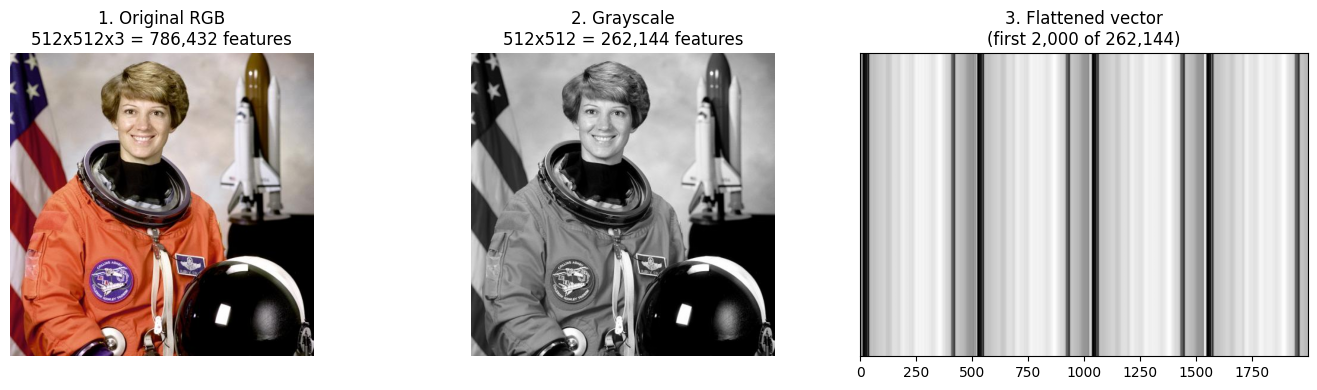

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(original_image)
axes[0].set_title(f"1. Original RGB\n{h}x{w}x{c} = {h*w*c:,} features")
axes[0].axis('off')

axes[1].imshow(grayscale_image, cmap='gray')
axes[1].set_title(f"2. Grayscale\n{h}x{w} = {h*w:,} features")
axes[1].axis('off')

axes[2].imshow(flattened_features[:2000].reshape(1, -1), cmap='gray', aspect='auto')
axes[2].set_title(f"3. Flattened vector\n(first 2,000 of {flattened_features.size:,})")
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

## Discussion questions (Part B) — Answers

**1. How does grayscale conversion act as a simple feature-engineering technique?**
Grayscale conversion maps the three colour channels (R, G, B) of every pixel onto **one luminance value**, $L = 0.299R + 0.587G + 0.114B$. It is feature engineering because it *transforms and reduces* the raw input using domain knowledge: for many tasks (digits, edges, shapes, textures) brightness structure carries the signal and colour is redundant. It cuts the number of features **three-fold** ($H\times W\times 3 \to H\times W$), lowering memory, computation and the risk of over-fitting, at the cost of **all colour information**.

**2. What is the length of the flattened vector after grayscale conversion of an $H \times W$ image?**
$H \times W$ (one intensity value per pixel; the three channels have already been collapsed). For the sample image, $512 \times 512 = 262{,}144$; for a $100\times100$ image, $10{,}000$.

**3. Why is flattening necessary before Logistic Regression or an SVM?**
These models expect a **2-D design matrix of shape (n_samples, n_features)**, in which each sample is **one row vector**. An image is a 2-D (or 3-D) grid, so it must be unrolled (row-major) into a 1-D vector to become one row of that matrix; the model then learns one weight per pixel position. The price is that the **spatial neighbourhood structure is discarded**: the model cannot know that pixel *i* and pixel *i + W* are vertical neighbours. (Convolutional networks avoid this by working on the grid directly — Laboratory 8.)

**4. Why resize all images to a consistent size (e.g. $64\times64$) first?**
- **Fixed vector length:** images of different sizes would give vectors of different lengths that cannot be stacked into one matrix or fed to a model with a fixed number of inputs.
- **Feature alignment:** with equal size, feature *j* always refers to the *same spatial location* in every image, so weights learned for it are comparable across images.
- **Efficiency and control of dimensionality:** a 64×64 image has 4,096 features instead of hundreds of thousands, reducing memory, training time and over-fitting risk.
- Trade-off: fine detail is lost (and aspect ratio distorted if the image is not square).

---
# Home-Lab Exercise 3 — 64×64 and 32×32 versions of a real photograph

Original  (512, 512) -> flattened length 262,144
64 x 64              -> flattened length 4,096
32 x 32              -> flattened length 1,024


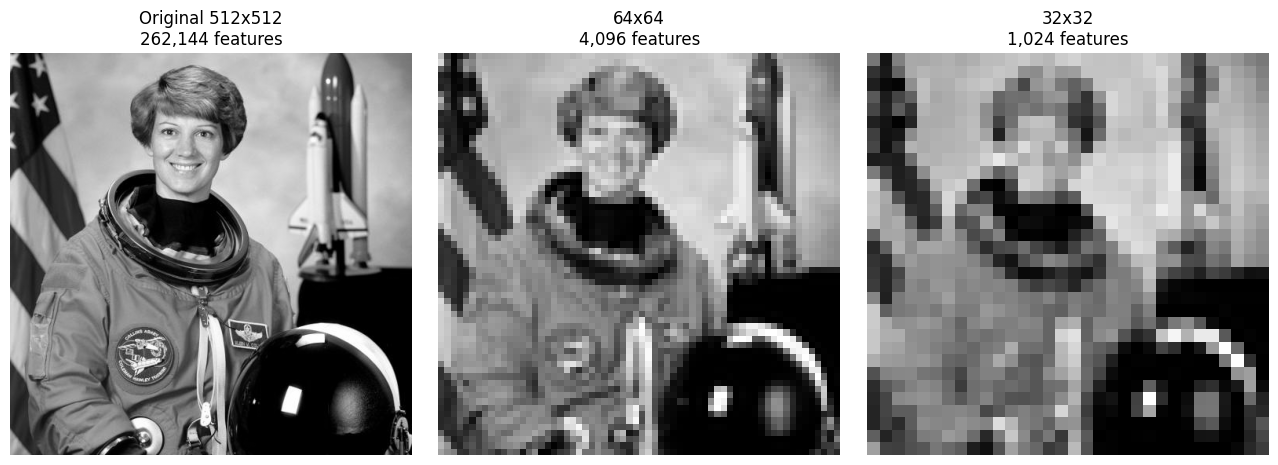

In [5]:
photo = Image.open("sample_images/photo.jpg").convert("RGB")
gray_orig = photo.convert("L")

g64 = photo.resize((64, 64), Image.LANCZOS).convert("L")
g32 = photo.resize((32, 32), Image.LANCZOS).convert("L")

v_orig = np.array(gray_orig).flatten()
v64 = np.array(g64).flatten()
v32 = np.array(g32).flatten()

print(f"Original  {photo.size[::-1]} -> flattened length {v_orig.size:,}")
print(f"64 x 64              -> flattened length {v64.size:,}")
print(f"32 x 32              -> flattened length {v32.size:,}")

fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
ax[0].imshow(gray_orig, cmap='gray');  ax[0].set_title(f"Original 512x512\n{v_orig.size:,} features")
ax[1].imshow(g64, cmap='gray');        ax[1].set_title(f"64x64\n{v64.size:,} features")
ax[2].imshow(g32, cmap='gray');        ax[2].set_title(f"32x32\n{v32.size:,} features")
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

**Result.** Flattened lengths (after grayscale): original $512\times512$ = **262,144**; $64\times64$ = **4,096**; $32\times32$ = **1,024**.

**What is no longer visible.** At 64×64 the overall pose, face/helmet shape and large light–dark regions survive, but fine detail (fabric texture, small lettering/patches, hair, sharp edges) is gone and edges look blocky. At 32×32 only very coarse blobs remain: the face is barely recognisable, small objects disappear and individual pixels are clearly visible. Each halving of the side length removes 75 % of the pixels; the discarded information is **high-spatial-frequency detail**, and it cannot be recovered by enlarging the image again.

---
# Home-Lab Exercise 4 — `image_to_features(path, size)`
The function lives in **`image_utils.py`** (deliverable) and is imported here.

In [6]:
from image_utils import image_to_features
import inspect
print(inspect.getsource(image_to_features))

def image_to_features(path, size=(64, 64), normalize=False):
    """Convert an image file into a fixed-length grayscale pixel vector.

    Parameters
    ----------
    path : str or path-like
        Location of the image file (jpg, png, ...).
    size : tuple[int, int], default (64, 64)
        Target (width, height) in pixels, applied BEFORE grayscale/flatten.
        Because every image is resized to this size, the output length is
        always ``size[0] * size[1]`` regardless of the input dimensions.
    normalize : bool, default False
        If True return float32 values scaled to [0, 1]; otherwise uint8 0-255.

    Returns
    -------
    numpy.ndarray, shape (size[0] * size[1],)
        Row-major flattened grayscale pixel intensities.

    Notes
    -----
    * Resizing discards fine detail; grayscale discards all colour;
      flattening discards the 2-D neighbourhood structure.
    * Images are converted to 'RGB' first so palette / RGBA / greyscale
      files all follow t

In [7]:
paths = ["sample_images/photo.jpg", "sample_images/cat.jpg", "sample_images/coffee.jpg"]
lengths = []
for p in paths:
    with Image.open(p) as im_:
        print(f"{p:26s} original size (W,H) = {im_.size}")
    vec = image_to_features(p, size=(64, 64))
    lengths.append(len(vec))
    print(f"{'':26s} feature vector: shape={vec.shape}, dtype={vec.dtype}")

print()
print("Lengths:", lengths)
assert set(lengths) == {64 * 64}
print("OK: all three differently sized images produce the SAME length (4096).")

sample_images/photo.jpg    original size (W,H) = (512, 512)
                           feature vector: shape=(4096,), dtype=uint8
sample_images/cat.jpg      original size (W,H) = (451, 300)
                           feature vector: shape=(4096,), dtype=uint8
sample_images/coffee.jpg   original size (W,H) = (600, 400)
                           feature vector: shape=(4096,), dtype=uint8

Lengths: [4096, 4096, 4096]
OK: all three differently sized images produce the SAME length (4096).


---
# Home Assignment — 20-image, two-class dataset

Because no photographs were supplied, `make_sample_data.py` generates **20 synthetic images of varying sizes and colours**: 10 *circle* images (class 0, `data/class_a/`) and 10 *stripe* images (class 1, `data/class_b/`). To use your own classes (e.g. cats vs dogs), simply replace the files in those two folders and re-run the cell below.

In [8]:
from glob import glob

CLASS_DIRS = {0: "data/class_a", 1: "data/class_b"}
SIZE = (64, 64)

X_list, y_list = [], []
for label, folder in CLASS_DIRS.items():
    paths = sorted(glob(os.path.join(folder, "*")))
    for p in paths:
        try:
            X_list.append(image_to_features(p, size=SIZE))
            y_list.append(label)
        except Exception as e:
            print(f"[SKIP] {p} -> {e}")

if X_list:
    X = np.vstack(X_list)
    y = np.array(y_list)
    np.savez("dataset.npz", X=X, y=y)

    print(f"X shape: {X.shape}   y shape: {y.shape}")
    print(f"Samples: {X.shape[0]}   Features per sample: {X.shape[1]}")
    print(f"Samples per feature: {X.shape[0] / X.shape[1]:.4f}")
    print()
    print("Saved dataset.npz")
else:
    print("No images found. Create data/class_a and data/class_b and add images.")

X shape: (20, 4096)   y shape: (20,)
Samples: 20   Features per sample: 4096
Samples per feature: 0.0049

Saved dataset.npz


In [9]:
# Verify the saved file
d = np.load("dataset.npz")
print("Keys:", d.files, "| X:", d['X'].shape, d['X'].dtype, "| y:", d['y'].shape, "| class counts:", np.bincount(d['y']))

Keys: ['X', 'y'] | X: (20, 4096) uint8 | y: (20,) | class counts: [10 10]


**Dimensionality of the feature space:** $64 \times 64 = $ **4,096 dimensions**; the dataset is $X \in \mathbb{R}^{20 \times 4096}$ with $y \in \{0,1\}^{20}$.

**Is twenty samples in 4,096 dimensions a sound basis for learning?** No. With only 20 samples for 4,096 features the ratio is ≈ 0.005 samples per feature, far below what is needed to estimate a model reliably. Because $p \gg n$, the data are always **linearly separable** in such a space, so a linear model (Logistic Regression, SVM) can fit the 20 training points perfectly by exploiting arbitrary pixel-level noise — it will **over-fit** and its training accuracy says nothing about generalisation. This is the **curse of dimensionality**: volume grows exponentially with the number of dimensions, the 20 points are extremely sparse in that space, distances become nearly uniform, and the number of samples required to cover the space grows exponentially. Moreover, each of the 4,096 pixel features is highly redundant with its neighbours, so the *effective* dimensionality of the data is much smaller than 4,096 — which is exactly what **dimensionality reduction (Laboratory 6: PCA, etc.)** exploits by projecting onto a few informative components, and what a **CNN (Laboratory 8)** exploits by sharing a small set of local filters across the image instead of learning one independent weight per pixel. Data augmentation, more samples, strong regularisation and cross-validation are further mitigations.